
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



In [2]:
#Solución Inciso 1

torgersen = df[df['isla']=='Torgersen'] #Seleccionamos todos los pinguinos de la isla Torgersen

prof_max = np.max(torgersen['profundidad_pico (mm)'])
prof_min = np.min(torgersen['profundidad_pico (mm)'])

print('La profundidad del pico máxima corresponde a:', prof_max, 'mm', '\nLa profundidad del pico mínima corresponde a:', prof_min, 'mm')

La profundidad del pico máxima corresponde a: 21.5 mm 
La profundidad del pico mínima corresponde a: 15.9 mm


In [3]:
#Solución Inciso 2

indice_max_masa = np.argmax(df['masa_corporal (g)']) #me devuelve la ubicación del número mas grande
pinguino_max_masa = df.iloc[indice_max_masa] #toda la información de esa fila 


print('El pinguino con mayor masa corporal tiene las siguientes características: \nIsla:', pinguino_max_masa['isla'], '\nEspecie:', pinguino_max_masa['especie'], '\nGénero:', pinguino_max_masa['genero'])
print('Masa Corporal:', pinguino_max_masa['masa_corporal (g)'], 'g')

El pinguino con mayor masa corporal tiene las siguientes características: 
Isla: Biscoe 
Especie: Gentoo 
Género: Male
Masa Corporal: 6300.0 g


In [4]:
#Solución Inciso 3

gentoo = df[np.logical_and(df.especie != 'Gentoo', df.genero == 'Male')] #me permite filtrar dos condiciones al mismo tiempo

media_masac = np.mean(gentoo['masa_corporal (g)'])

print(f'La masa corporal media de los pinguinos que no son de la especie Gentoo es: {media_masac:.2f} g')

La masa corporal media de los pinguinos que no son de la especie Gentoo es: 4010.28 g


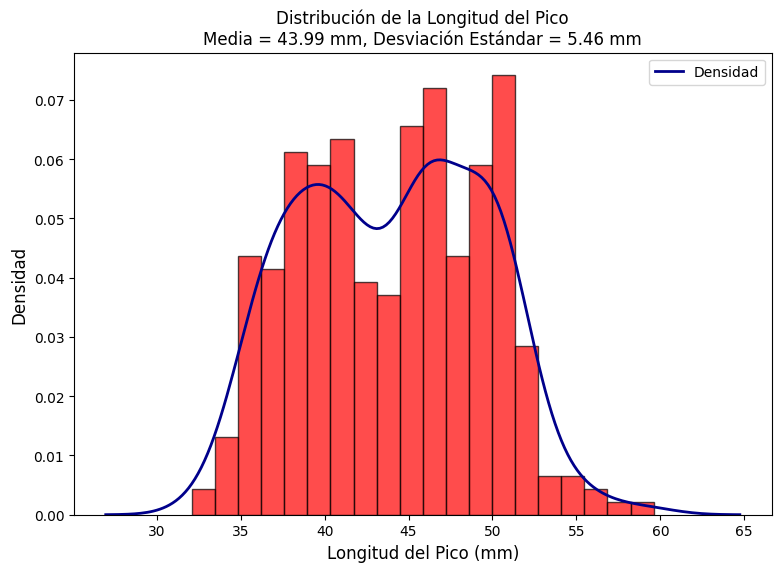

In [7]:
#Solución Inciso 4

media_longitud = np.mean(df['longitud_pico (mm)'])
std_longitud = np.std(df['longitud_pico (mm)'])

#Gráfica
plt.figure(figsize=(9, 6))
plt.hist(df['longitud_pico (mm)'], bins=20, edgecolor='black', alpha=0.7, color='red', density=True)
sns.kdeplot(df["longitud_pico (mm)"], color='darkblue', linewidth=2, label='Densidad') #densidad de probabilidad
plt.xlabel('Longitud del Pico (mm)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.title(f'Distribución de la Longitud del Pico\nMedia = {media_longitud:.2f} mm, Desviación Estándar = {std_longitud:.2f} mm', 
          fontsize=12)
plt.legend()
#plt.grid(alpha=0.2)
plt.show()

In [31]:
#Solución Inciso 5

islas = df['isla'].value_counts()
especies = df['especie'].value_counts()

print('Islas presentes en el conjunto de datos:',islas, '\nEspecies presentes en el conjunto de datos:', especies)


Islas presentes en el conjunto de datos: isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64 
Especies presentes en el conjunto de datos: especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


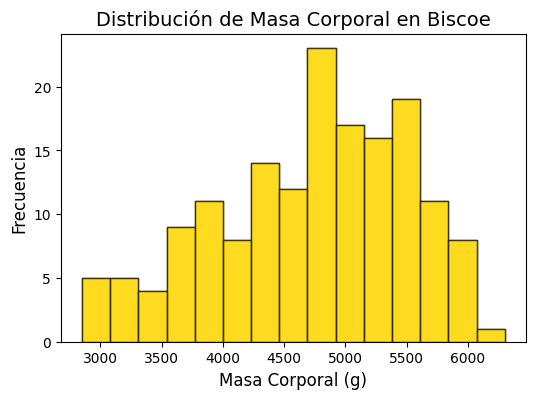

In [38]:
#Gráficas de islas

plt.figure(figsize=(6,4))
for isla in islas.index: #obtiene los nombres de las islas
    plt.hist(df[df['isla'] == 'Biscoe']['masa_corporal (g)'], bins=15, alpha=0.5, edgecolor='black', color='gold')

plt.title('Distribución de Masa Corporal en Biscoe', fontsize=14)
plt.xlabel('Masa Corporal (g)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

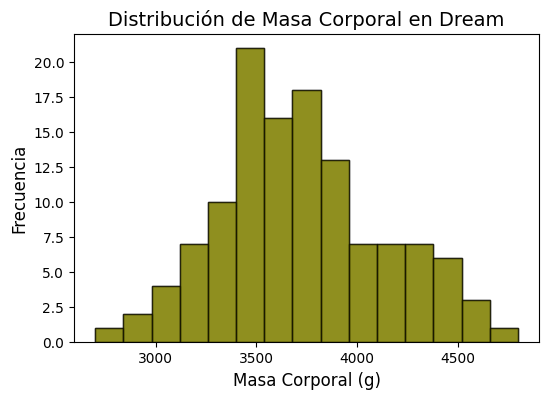

In [39]:
plt.figure(figsize=(6,4))
for isla in islas.index: #obtiene los nombres de las islas
    plt.hist(df[df['isla'] == 'Dream']['masa_corporal (g)'], bins=15, alpha=0.5, edgecolor='black', color='olive')

plt.title('Distribución de Masa Corporal en Dream', fontsize=14)
plt.xlabel('Masa Corporal (g)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

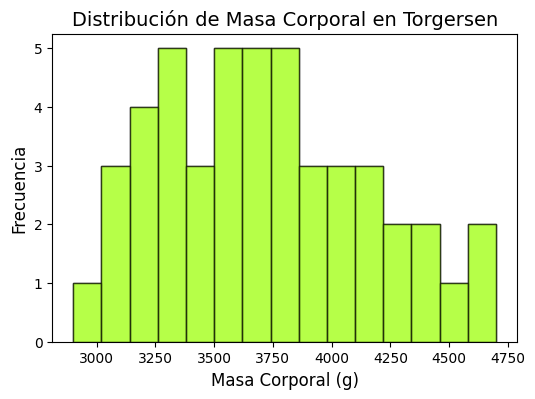

In [40]:
plt.figure(figsize=(6,4))
for isla in islas.index: #obtiene los nombres de las islas
    plt.hist(df[df['isla'] == 'Torgersen']['masa_corporal (g)'], bins=15, alpha=0.5, edgecolor='black', color='greenyellow')

plt.title('Distribución de Masa Corporal en Torgersen', fontsize=14)
plt.xlabel('Masa Corporal (g)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

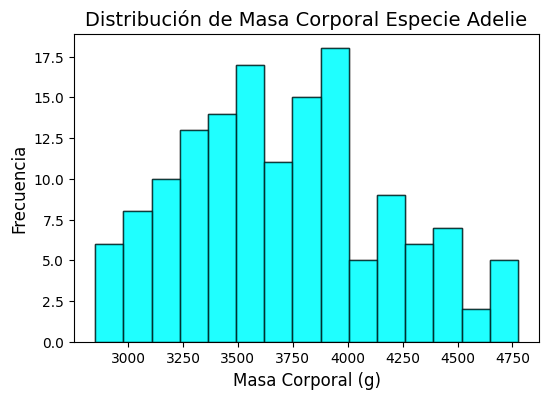

In [41]:
#Gráficas por Especie

plt.figure(figsize=(6,4))
for especie in especies.index: #obtiene los nombres de las islas
    plt.hist(df[df['especie'] == 'Adelie']['masa_corporal (g)'], bins=15, alpha=0.5, edgecolor='black', color='cyan')

plt.title('Distribución de Masa Corporal Especie Adelie', fontsize=14)
plt.xlabel('Masa Corporal (g)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

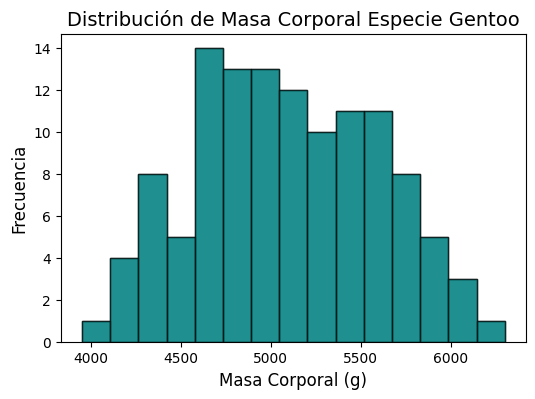

In [42]:
plt.figure(figsize=(6,4))
for especie in especies.index: #obtiene los nombres de las islas
    plt.hist(df[df['especie'] == 'Gentoo']['masa_corporal (g)'], bins=15, alpha=0.5, edgecolor='black', color='teal')

plt.title('Distribución de Masa Corporal Especie Gentoo', fontsize=14)
plt.xlabel('Masa Corporal (g)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

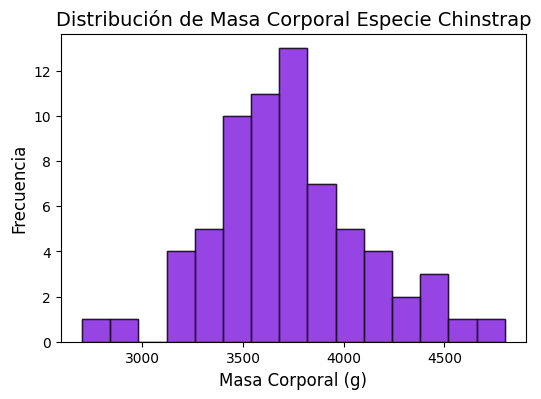

In [43]:
plt.figure(figsize=(6,4))
for especie in especies.index: #obtiene los nombres de las islas
    plt.hist(df[df['especie'] == 'Chinstrap']['masa_corporal (g)'], bins=15, alpha=0.5, edgecolor='black', color='blueviolet')

plt.title('Distribución de Masa Corporal Especie Chinstrap', fontsize=14)
plt.xlabel('Masa Corporal (g)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

MUY BIEN NOTA 4.8... EN EL ULTIMO ITME TODO PUEDE IR EN UN HIST